<a href="https://colab.research.google.com/github/kireykale/Broadway-Project/blob/master/Object_Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
!kaggle datasets download -d mostafaabla/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:13<00:00, 18.5MB/s]



In [3]:
!rm -rf /content/Garbage classification

In [4]:
!unzip garbage-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: garbage_classification/paper/paper381.jpg  
  inflating: garbage_classification/paper/paper382.jpg  
  inflating: garbage_classification/paper/paper383.jpg  
  inflating: garbage_classification/paper/paper384.jpg  
  inflating: garbage_classification/paper/paper385.jpg  
  inflating: garbage_classification/paper/paper386.jpg  
  inflating: garbage_classification/paper/paper387.jpg  
  inflating: garbage_classification/paper/paper388.jpg  
  inflating: garbage_classification/paper/paper389.jpg  
  inflating: garbage_classification/paper/paper39.jpg  
  inflating: garbage_classification/paper/paper390.jpg  
  inflating: garbage_classification/paper/paper391.jpg  
  inflating: garbage_classification/paper/paper392.jpg  
  inflating: garbage_classification/paper/paper393.jpg  
  inflating: garbage_classification/paper/paper394.jpg  
  inflating: garbage_classification/paper/paper395.jpg  
  inflating: garbage_classification/pa

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/garbage_classification",   # change path if needed
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 15515 files belonging to 12 classes.


In [6]:
class_names = train_ds.class_names
print("Class Names: ",class_names)

Class Names:  ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [7]:
path = '/content/garbage_classification'
train_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.


In [18]:
# check if data is loading correctly
for images, labels in train_ds.take(1):
    print("Image min:", images.numpy().min())
    print("Image max:", images.numpy().max())
    print("Labels:", labels.numpy())

Image min: 0.0
Image max: 255.0
Labels: [ 9  5  1  6  4  4  6  1 11 11  4  3  1  8  4  9  8  6  4  1  8  0  4  0
  9  4  4 10 11  1  1 11]


In [19]:
model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(12, activation='softmax')  # dynamic output
])

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 37s 84ms/step - accuracy: 0.4278 - loss: 1.7855 - val_accuracy: 0.4902 - val_loss: 1.5469
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.5391 - loss: 1.4089 - val_accuracy: 0.5965 - val_loss: 1.2226
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.5905 - loss: 1.2426 - val_accuracy: 0.6252 - val_loss: 1.1323
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.6268 - loss: 1.1362 - val_accuracy: 0.6561 - val_loss: 1.0558
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 43s 75ms/step - accuracy: 0.6449 - loss: 1.0695 - val_accuracy: 0.6568 - val_loss: 1.0230
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.6640 - loss: 1.0166 - val_accuracy: 0.6600 - val_loss: 1.0120
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.6880 - loss: 0.9569 - val_accuracy: 0.6906 - val_loss: 0.9335
Epoch 8/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.7028 - loss: 0.9049 - 

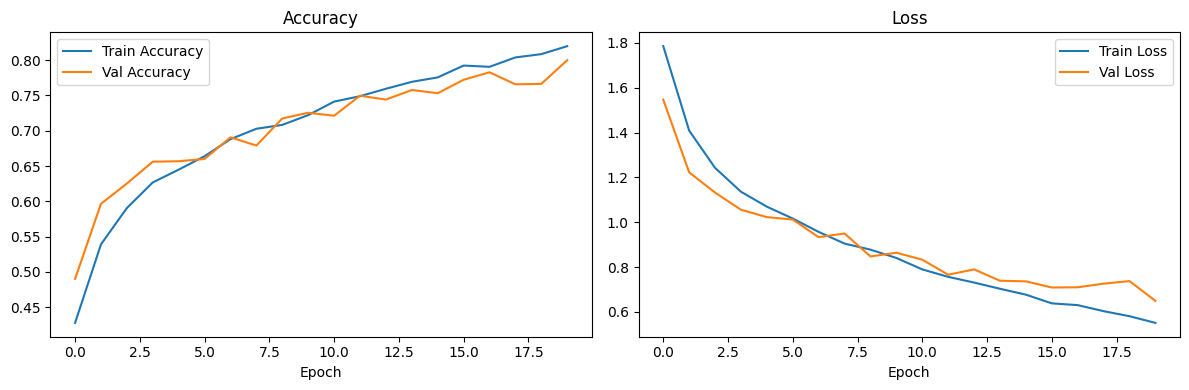

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


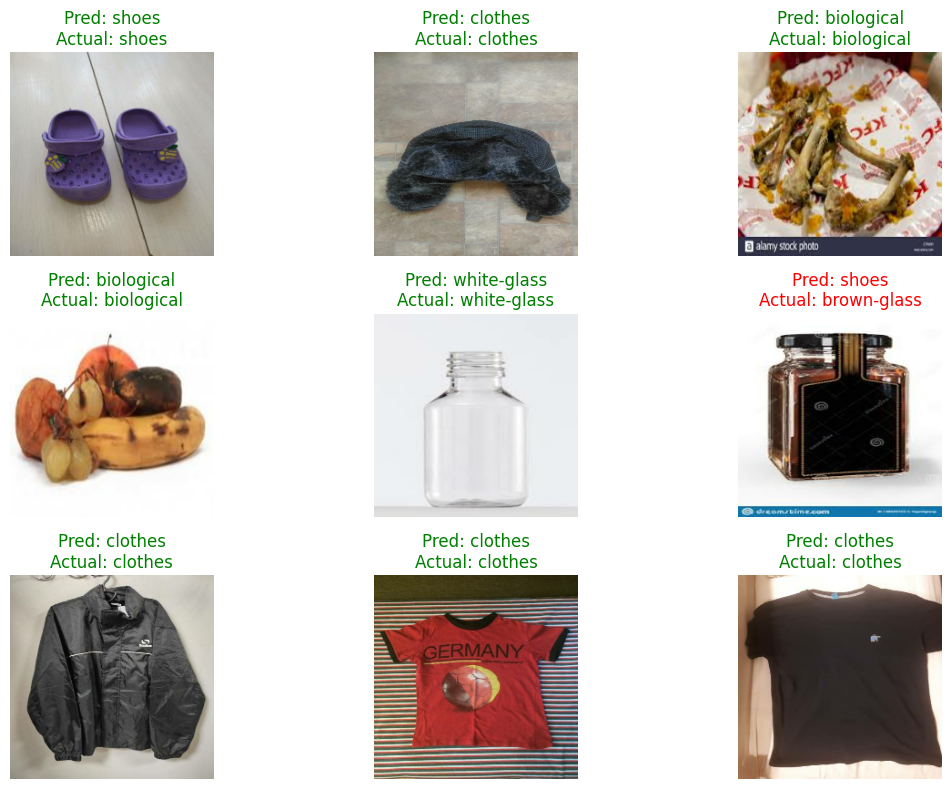

In [25]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(12, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred = class_names[tf.argmax(predictions[i]).numpy()]
        actual = class_names[labels[i].numpy()]
        color = 'green' if pred == actual else 'red'
        plt.title(f"Pred: {pred}\nActual: {actual}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

#User input Prediction

Saving cardboard.jpg to cardboard (2).jpg
Saving Mono_Battery.jpg to Mono_Battery (2).jpg
Saving red meat.jpg to red meat (5).jpg
Saving rotten image.jpg to rotten image (3).jpg
Saving shoe.jpg to shoe (3).jpg


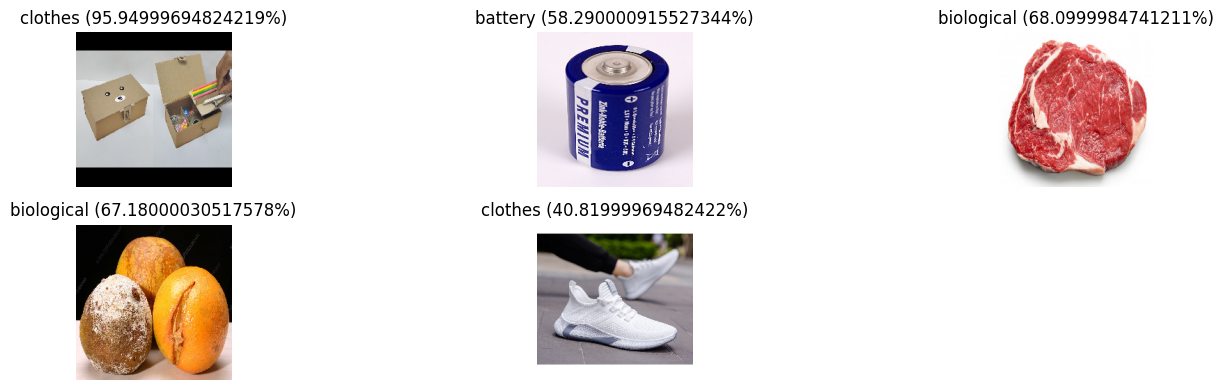

In [33]:
from google.colab import files

uploaded = files.upload()  # select 3 images
n = len(uploaded)
cols = 3
rows = (n // cols) + (1 if n % cols != 0 else 0)

plt.figure(figsize=(15, 2 * rows))

for i, (filename, content) in enumerate(uploaded.items()):
    # save to disk
    with open(filename, 'wb') as f:
        f.write(content)

    img = tf.keras.utils.load_img(filename, target_size=(224, 224))
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[tf.argmax(predictions[0]).numpy()]
    confidence = round(tf.reduce_max(predictions[0]).numpy() * 100, 2)

    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()